# 3 — Batches, uncertainties, and how far to trust the output

Notebooks 1 and 2 got a spectrum through the model. This one is about **whether to believe the
answer**, which for a generative model is the harder question.

Everything below is computed live from the 24 sample galaxies, so these are the model's actual
numbers, not quoted ones. The sample is small — treat it as illustration and see the paper for
the full held-out set.

> **All 24 are held-out galaxies, and the numbers below depend on that.** Training augments each
> galaxy into 21 near-identical rows differing only by a small redshift shift and noise, so a
> split drawn *by row* would put near-duplicates of a test galaxy into training and every number
> on this page would be optimistic. The split is drawn over **parent galaxies** instead, and
> augmentation is applied to the training side only, so a held-out galaxy contributes exactly one
> row — its real observed spectrum, with no synthetic copy anywhere in training. Each of these 24
> was checked against the split that produced the released weights and all 24 are on the held-out
> side. The failure rates you are about to see are therefore real, not an artefact of an easy
> sample.

> **These weights are un-tuned.** Hyperparameters come from an early sweep, and the released
> checkpoints are known to be selected on the wrong criterion. Expect the numbers here to
> improve. They are shown because a tutorial that hides a model's failure modes is useless.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from specsr.inference import SpecSRPipeline

pipeline = SpecSRPipeline.from_pretrained()

data = np.load("sample_24_spectra.npz", allow_pickle=True)
wavelength = data["wavelength"]
flux_low   = data["flux_low"]      # (24, 6671)
flux_high  = data["flux_high"]
z_true     = data["z"]

print(f"{flux_low.shape[0]} spectra, z from {z_true.min():.2f} to {z_true.max():.2f}")

24 spectra, z from 0.31 to 9.43


## Batch inference

Pass a 2-D array. `batch_size` controls GPU chunking, not the result.

In [2]:
result = pipeline(flux_low, batch_size=8)
print("sr2:", result.sr2.shape, " z:", result.z.shape)

sr2: (24, 6671)  z: (24,)


## Redshift: accuracy and honesty are different questions

**Accuracy** is how close the prediction is. **Calibration** is whether the quoted uncertainty
matches the actual error. A model can be accurate and overconfident, or inaccurate but honest.

In [3]:
z_pred, z_sig = result.z, result.z_sigma
dz = z_pred - z_true
scaled = np.abs(dz) / (1 + z_true)

sigma_nmad = 1.4826 * np.median(np.abs(dz/(1+z_true) - np.median(dz/(1+z_true))))
outliers = scaled > 0.15          # the usual "catastrophic" threshold

print(f"median |dz|/(1+z)  : {np.median(scaled):.4f}")
print(f"sigma_NMAD         : {sigma_nmad:.4f}")
print(f"catastrophic (>15%): {outliers.sum()}/{len(z_true)}  ({outliers.mean():.1%})")
print()
print(f"within quoted 1 sigma: {(np.abs(dz) < z_sig).mean():.1%}   (calibrated would be ~68%)")

median |dz|/(1+z)  : 0.1002
sigma_NMAD         : 0.1585
catastrophic (>15%): 9/24  (37.5%)

within quoted 1 sigma: 66.7%   (calibrated would be ~68%)


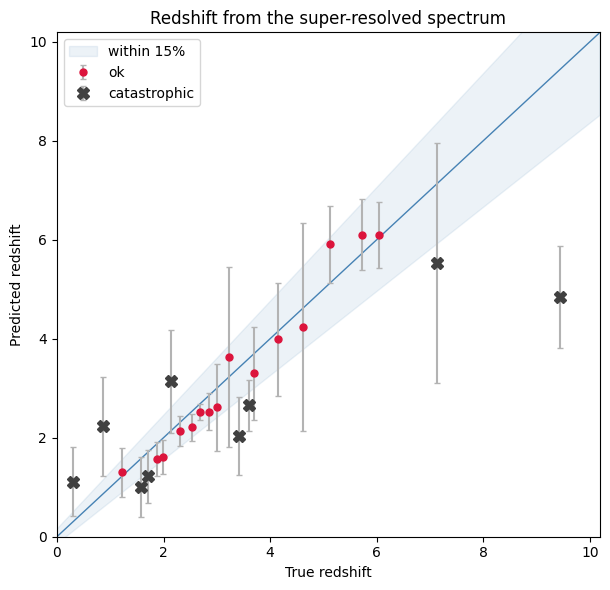

In [4]:
fig, ax = plt.subplots(figsize=(6.2, 6))
lim = [0, max(z_true.max(), z_pred.max()) * 1.08]
ax.plot(lim, lim, color="steelblue", lw=1)
ax.fill_between(lim, [l*0.85 - 0.15 for l in lim], [l*1.15 + 0.15 for l in lim],
                color="steelblue", alpha=0.10, label="within 15%")
ax.errorbar(z_true[~outliers], z_pred[~outliers], yerr=z_sig[~outliers],
            fmt="o", ms=5, color="crimson", ecolor="0.7", capsize=2, label="ok")
ax.errorbar(z_true[outliers], z_pred[outliers], yerr=z_sig[outliers],
            fmt="X", ms=9, color="0.25", ecolor="0.7", capsize=2, label="catastrophic")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("True redshift"); ax.set_ylabel("Predicted redshift")
ax.set_title("Redshift from the super-resolved spectrum")
ax.legend(); fig.tight_layout()

The calibration figure is usually close to 68%, which is genuinely good — the model's error bars
mean roughly what they claim *on average*.

The failures are a different story. They are not small errors but large ones, typically a line
**misidentification**: the model fits the wrong line to a feature and lands at a completely
different redshift. There is no smooth path between the right answer and the wrong one, so the
error distribution is bimodal, and a small `z_sigma` is not proof the redshift is right.

Note also that this sample deliberately spans to z~9, past where training data is dense. The
high-redshift end is where most of the failures sit.

**If the redshift matters to you, check that the implied line positions land on real features.**

## Where the model says it is unsure

`sr2_sigma` is a per-wavelength uncertainty and is the most useful output for deciding which
parts of a reconstruction to trust.

As in notebook 1, we standardise both sides — the model does not predict absolute flux scale.

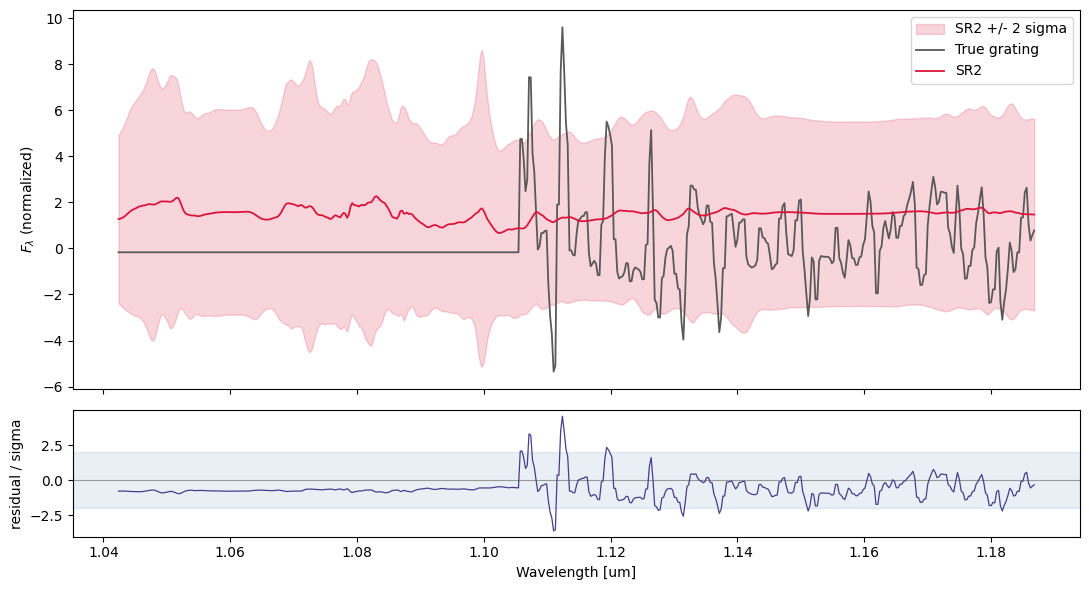

In [5]:
def standardise(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / np.nanstd(x)

i = int(np.argmin(np.abs(z_true - np.median(z_true))))
sr2_n = standardise(result.sr2[i])
hr_n  = standardise(flux_high[i])
sig_n = result.sr2_sigma[i] / np.nanstd(result.sr2[i])

peak = int(np.nanargmax(np.where(np.isfinite(flux_high[i]), flux_high[i], -np.inf)))
sl = slice(max(0, peak-260), min(len(wavelength), peak+260))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
axes[0].fill_between(wavelength[sl], (sr2_n-2*sig_n)[sl], (sr2_n+2*sig_n)[sl],
                     color="crimson", alpha=0.18, label="SR2 +/- 2 sigma")
axes[0].plot(wavelength[sl], hr_n[sl],  lw=1.3, color="0.35", label="True grating")
axes[0].plot(wavelength[sl], sr2_n[sl], lw=1.3, color="crimson", label="SR2")
axes[0].set_ylabel(r"$F_\lambda$ (normalized)"); axes[0].legend()

axes[1].axhline(0, color="0.6", lw=0.8)
axes[1].plot(wavelength[sl], ((hr_n - sr2_n)/sig_n)[sl], lw=0.9, color="darkslateblue")
axes[1].axhspan(-2, 2, color="steelblue", alpha=0.12)
axes[1].set_ylabel("residual / sigma"); axes[1].set_xlabel("Wavelength [um]")
fig.tight_layout()

The lower panel is the residual divided by the model's own uncertainty. Perfect uncertainties
would keep it inside the shaded band ~95% of the time. Excursions outside are places the model
is wrong by more than it admits — and they cluster at line cores, which is where the science is.

## Line flux is the weak point

If you plan to measure **integrated line fluxes** from the reconstruction, read this section.

Recovery is a strong function of line brightness: bright lines keep most of their flux, faint
ones are systematically under-recovered towards zero. There is no single "flux accuracy" number
for this model, and any figure quoted without a signal-to-noise attached is meaningless.

median recovery, overall       : 0.466
median recovery, brightest half: 0.466
median recovery, faintest half : 0.394


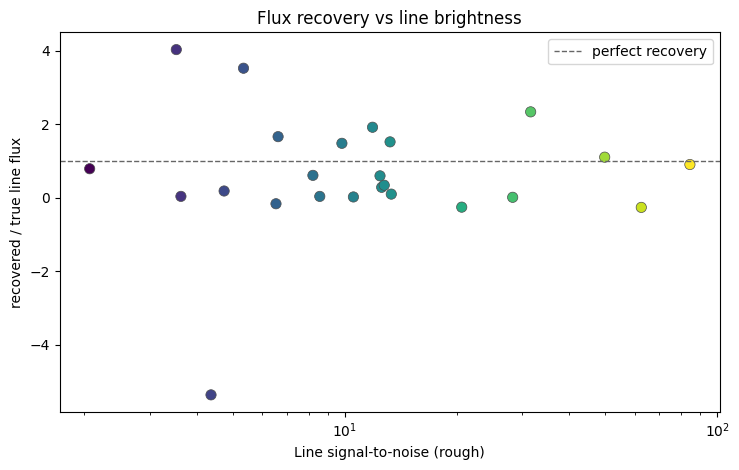

In [6]:
trapz = getattr(np, "trapezoid", np.trapz)

def line_flux(w, f, lam0, half=0.006, off=0.020):
    sel  = np.abs(w - lam0) < half
    side = (np.abs(w - lam0) > off) & (np.abs(w - lam0) < off + 2*half)
    return trapz(f[sel] - np.nanmedian(f[side]), w[sel])

ratio, snr = [], []
for k in range(len(z_true)):
    fh = flux_high[k].astype(float)
    ok = np.isfinite(fh)
    if ok.sum() < 500:
        continue
    lam0 = wavelength[int(np.nanargmax(np.where(ok, fh, -np.inf)))]
    noise = np.nanstd(fh[ok][:400])
    if not np.isfinite(noise) or noise <= 0:
        continue
    # Standardise BOTH sides: the model does not predict absolute scale, so a
    # raw ratio here would just be measuring the scale mismatch.
    truth = line_flux(wavelength, standardise(fh), lam0)
    rec   = line_flux(wavelength, standardise(result.sr2[k]), lam0)
    if not np.isfinite(truth) or truth <= 0:
        continue
    ratio.append(rec / truth); snr.append(np.nanmax(fh) / noise)

ratio, snr = np.asarray(ratio), np.asarray(snr)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(snr, ratio, c=np.log10(snr), cmap="viridis", s=55, edgecolor="0.3", lw=0.5)
ax.axhline(1.0, color="0.4", ls="--", lw=1, label="perfect recovery")
ax.set_xscale("log")
ax.set_xlabel("Line signal-to-noise (rough)"); ax.set_ylabel("recovered / true line flux")
ax.set_title("Flux recovery vs line brightness")
ax.legend(); fig.tight_layout()

print(f"median recovery, overall       : {np.median(ratio):.3f}")
print(f"median recovery, brightest half: {np.median(ratio[snr > np.median(snr)]):.3f}")
print(f"median recovery, faintest half : {np.median(ratio[snr <= np.median(snr)]):.3f}")

The *trend* is the point, not the exact values: 24 galaxies, a crude continuum estimate, and a
fixed window that does not deblend neighbouring lines. The paper measures this properly, per
line, with fitted profiles on the full validation set, and reports substantially better recovery
for the brightest lines than this crude estimate suggests.

## Summary: when to trust it

**Reasonable:**

- recovering the *positions* and *widths* of bright emission lines
- deblending doublets the prism cannot separate — the model's main claim
- a first-pass redshift, verified against the line positions it implies

**Be careful:**

- integrated fluxes, especially of faint lines — systematically under-recovered
- absolute flux scale — not predicted at all; work in normalized units
- anything outside your input's wavelength coverage — extrapolation
- redshifts taken on trust; failures are large and not always flagged
- `sr2_sigma` as a complete error budget; it under-covers at line cores

**Do not:**

- feed it spectra unlike JADES prism data and expect the uncertainties to mean anything
- use a reconstruction as if it were an observation. It is a prediction conditioned on one, and
  the honest way to report it says so.

## Where to go next

- `specsr infer --help` — the same pipeline from the command line, for bulk runs
- the paper (arXiv:2603.18357) for architecture, training and full validation
- `specsr train --help` to retrain on your own paired data